<a href="https://colab.research.google.com/github/jan1jacob2/Loan-Status/blob/master/Model_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Choosing the Best Model

In [6]:
! pip install xgboost

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV, TunedThresholdClassifierCV
from sklearn.metrics import classification_report, roc_curve, make_scorer, fbeta_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [8]:
# loanDF = pd.read_csv('./data/loan.csv.')
loanDF = pd.read_csv('loan.csv')
loanDF.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [9]:
onehot = pd.get_dummies(loanDF['purpose'], dtype = int)
loanDF = pd.concat([onehot, loanDF.drop(['purpose'], axis = 1)], axis = 1)
loanDF.head()

,all_other,credit_card,debt_consolidation,educational,home_improvement,major_purchase,small_business,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,0,0,1,0,0,0,0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,0,1,0,0,0,0,0,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,0,0,1,0,0,0,0,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,0,0,1,0,0,0,0,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,0,1,0,0,0,0,0,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [10]:
loanDF.shape

(9578, 20)

In [11]:
X = loanDF.iloc[:, :-1]
y = loanDF.iloc[:, -1]
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = .2, random_state = 42)

In [12]:
# The columns HTuned and TTuned will contain the metric it was tuned on.
# If no tuning happened, then the value will say 'No'.
statsTrain = pd.DataFrame(columns = ['Model', 'HTuned', 'Params', 'TTuned', 'Threshold', 'TP', 'TN', 'FP', 'FN'])
statsTest = pd.DataFrame(columns = ['Model', 'HTuned', 'Params', 'TTuned', 'Threshold', 'TP', 'TN', 'FP', 'FN'])

In [13]:
def modelRunTrain(name, model):
  model.fit(Xtrain, ytrain)

  trainPreds = model.predict(Xtrain)

  print(f'Classification report for {name} training set \n \n {classification_report(ytrain, trainPreds)}')

  modelTrainConMat = confusion_matrix(ytrain, trainPreds)
  modelTrainDisplay = ConfusionMatrixDisplay(confusion_matrix = modelTrainConMat)
  modelTrainDisplay.plot()

  plt.show()

  return trainPreds, modelTrainConMat

In [14]:
def modelRunTest(name, model):
  testPreds = model.predict(Xtest)

  print(f'Classification report for {name} testing set \n \n {classification_report(ytest, testPreds)}')

  modelTestConMat = confusion_matrix(ytest, testPreds)
  modelTestDisplay = ConfusionMatrixDisplay(confusion_matrix = modelTestConMat)
  modelTestDisplay.plot()

  plt.show()

  return testPreds, modelTestConMat

In [15]:
def plotRocTrain(name, trainPreds):
  fpr, tpr, thresholds = roc_curve(ytrain, trainPreds)
  plt.plot(fpr, tpr)
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'{name} ROC Curve for Training')
  plt.show()

In [16]:
def plotRocTest(name, testPreds):
  fpr, tpr, thresholds = roc_curve(ytest, testPreds)
  plt.plot(fpr, tpr)
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'{name} ROC Curve for Testing')
  plt.show()

In [17]:
def probDistTrain(name, model):
  probTrain = model.predict_proba(Xtrain)[:, 1]
  sns.histplot(x = probTrain, hue = ytrain, kde = True)
  plt.xlabel('Probabilities')
  plt.title(f'Probability Distribution Chart for {name} Training Set')
  plt.show()

In [18]:
def probDistTest(name, model):
  probTest = model.predict_proba(Xtest)[:, 1]
  sns.histplot(x = probTest, hue = ytest, kde = True)
  plt.xlabel('Probabilities')
  plt.title(f'Probability Distribution Chart for {name} Testing Set')
  plt.show()

In [23]:
def addToTrainDF(name, model, hMetric, tMetric, confusionMatrix):
  if tMetric == 'No':
    threshold = .5
  else:
    threshold = round(model.best_threshold_, 4)

  statsTrain.loc[len(statsTrain)] = [name, hMetric, model.get_params(), tMetric, threshold,
                       confusionMatrix[1][1], confusionMatrix[0][0],
                       confusionMatrix[0][1], confusionMatrix[1][0]]

In [24]:
def addToTestDF(name, model, hMetric, tMetric, confusionMatrix):
  if tMetric == 'No':
    threshold = .5
  else:
    threshold = round(model.best_threshold_, 4)

  statsTest.loc[len(statsTest)] = [name, hMetric, model.get_params(), tMetric, threshold,
                       confusionMatrix[1][1], confusionMatrix[0][0],
                       confusionMatrix[0][1], confusionMatrix[1][0]]

## Logistic Regression

### No Hyperparameter Tuning

#### No Threshold Tuning

In [ ]:
logReg = LogisticRegression()
logRegTrainPreds, logRegTrainConMat = modelRunTrain('Logistic Regression', logReg)
plotRocTrain('Logistic Regression', logRegTrainPreds)
addToTrainDF('Logistic Regression', logReg, 'No', 'No', logRegTrainConMat)

In [ ]:
logRegTestPreds, logRegTestConMat = modelRunTest('Logistic Regression', logReg)
plotRocTest('Logistic Regression', logRegTestPreds)
addToTestDF('Logistic Regression', logReg, 'No', 'No', logRegTestConMat)

#### With Threshold Tuning

In [ ]:
probDistTrain('Logistic Regression', logReg)

In [ ]:
probDistTest('Logistic Regression', logReg)

##### Tune for Balanced Accuracy


In [ ]:
logRegAcc = TunedThresholdClassifierCV(LogisticRegression(), cv = 5, scoring = 'balanced_accuracy')
logRegAccTrainPreds, logRegAccTrainConMat = modelRunTrain('Logistic Regression TTuned Balanced Accuracy', logRegAcc)
plotRocTrain('Logistic Regression TTuned Balanced Accuracy', logRegAccTrainPreds)
addToTrainDF('Logistic Regression', logRegAcc, 'No', 'Balanced Accuracy', logRegAccTrainConMat)

In [ ]:
logRegAccTestPreds, logRegAccTestConMat = modelRunTest('Logistic Regression TTuned Balanced Accuracy', logRegAcc)
plotRocTest('Logistic Regression TTuned Balanced Accuracy', logRegAccTestPreds)
addToTestDF('Logistic Regression', logRegAcc, 'No', 'Balanced Accuracy', logRegAccTestConMat)

##### Tune for Recall

In [ ]:
logRegRec = TunedThresholdClassifierCV(LogisticRegression(), cv = 5, scoring = 'recall')
logRegRecTrainPreds, logRegRecTrainConMat = modelRunTrain('Logistic Regression TTuned Recall', logRegRec)
plotRocTrain('Logistic Regression TTuned Recall', logRegRecTrainPreds)
addToTrainDF('Logistic Regression', logRegRec, 'No', 'Recall', logRegRecTrainConMat)

In [ ]:
logRegRecTestPreds, logRegRecTestConMat = modelRunTest('Logistic Regression TTuned Recall', logRegRec)
plotRocTest('Logistic Regression TTuned Recall', logRegRecTestPreds)
addToTestDF('Logistic Regression', logRegRec, 'No', 'Recall', logRegRecTestConMat)

##### Tune for F1 Micro

In [ ]:
logRegF1Micro = TunedThresholdClassifierCV(LogisticRegression(), cv = 5, scoring = 'f1_micro')
logRegF1MicroTrainPreds, logRegF1MicroTrainConMat = modelRunTrain('Logistic Regression TTuned F1 Micro', logRegF1Micro)
plotRocTrain('Logistic Regression TTuned F1 Micro', logRegF1MicroTrainPreds)
addToTrainDF('Logistic Regression', logRegF1Micro, 'No', 'F1 Micro', logRegF1MicroTrainConMat)

In [ ]:
logRegF1MicroTestPreds, logRegF1MicroTestConMat = modelRunTest('Logistic Regression TTuned F1 Micro', logRegF1Micro)
plotRocTest('Logistic Regression TTuned F1 Micro', logRegF1MicroTestPreds)
addToTestDF('Logistic Regression', logRegF1Micro, 'No', 'F1 Micro', logRegF1MicroTestConMat)

##### Tune for F1 Weighted

In [ ]:
logRegF1Weighted = TunedThresholdClassifierCV(LogisticRegression(), cv = 5, scoring = 'f1_weighted')
logRegF1TrainPreds, logRegF1TrainConMat = modelRunTrain('Logistic Regression TTuned F1 Weighted', logRegF1Weighted)
plotRocTrain('Logistic Regression TTuned F1 Weighted', logRegF1WeightedTrainPreds)
addToTrainDF('Logistic Regression', logRegF1Weighted, 'No', 'F1 Weighted', logRegF1WeightedTrainConMat)

In [ ]:
logRegF1WeightedTestPreds, logRegF1WeightedTestConMat = modelRunTest('Logistic Regression TTuned F1 Weighted', logRegF1Weighted)
plotRocTest('Logistic Regression TTuned F1 Weighted', logRegF1WeightedTestPreds)
addToTestDF('Logistic Regression', logRegF1Weighted, 'No', 'F1 Weighted', logRegF1WeightedTestConMat)

##### Tune for F2

In [ ]:
logRegF2 = TunedThresholdClassifierCV(LogisticRegression(), cv = 5, scoring = make_scorer(fbeta_score, beta = 2))
logRegF2TrainPreds, logRegF2TrainConMat = modelRunTrain('Logistic Regression TTuned F2', logRegF2)
plotRocTrain('Logistic Regression TTuned F2', logRegF2TrainPreds)
addToTrainDF('Logistic Regression', logRegF2, 'No', 'F2', logRegF2TrainConMat)

In [ ]:
logRegF2TestPreds, logRegF2TestConMat = modelRunTest('Logistic Regression TTuned F2', logRegF2)
plotRocTest('Logistic Regression TTuned F2', logRegF2TestPreds)
addToTestDF('Logistic Regression', logRegF2, 'No', 'F2', logRegF2TestConMat)

### With Hyperparameter Tuning

In [21]:
logRegParams = {'penalty': ['l1', 'l2', None],
                'tol': [.00001, .001, .05],
                'C': [.00005, .01, 1, 5],
                'class_weight': ['balanced', None],
                'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga', 'newton-cholesky'],
                'max_iter': [1, 1e2, 1e3],
                'l1_ratio': [0, .25, .33, .5, .66, .75, 1]}

#### No Threshold Tuning

##### Tune for Balanced Accuracy

In [25]:
logRegGSAcc = GridSearchCV(LogisticRegression(), param_grid = logRegParams, n_jobs = -1, cv = 5, scoring = 'balanced_accuracy')
logRegGSAccTrainPreds, logRegGSAccTrainConMat = modelRunTrain('Logistic Regression HTuned Balanced Accuracy', logRegGSAcc)
plotRocTrain('Logistic Regression HTuned Balanced Accuracy', logRegGSAccTrainPreds)
addToTrainDF('Logistic Regression', logRegGSAcc, 'Balanced Accuracy', 'No', logRegGSAccTrainConMat)

Classification report for Logistic Regression HTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.91      0.65      0.76      1611
           1       0.27      0.68      0.38       305

    accuracy                           0.66      1916
   macro avg       0.59      0.66      0.57      1916
weighted avg       0.81      0.66      0.70      1916



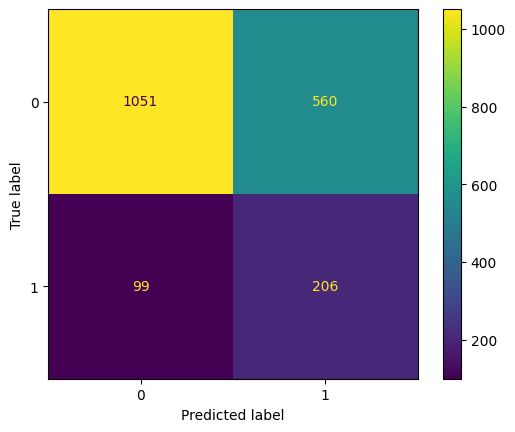

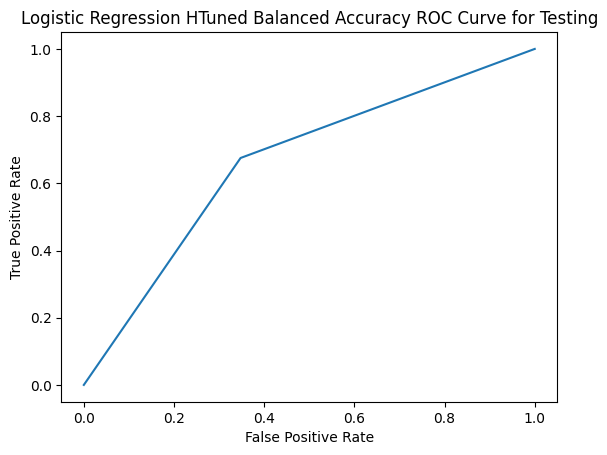

In [26]:
logRegGSAccTestPreds, logRegGSAccTestConMat = modelRunTest('Logistic Regression HTuned Balanced Accuracy', logRegGSAcc)
plotRocTest('Logistic Regression HTuned Balanced Accuracy', logRegGSAccTestPreds)
addToTestDF('Logistic Regression', logRegGSAcc, 'Balanced Accuracy', 'No', logRegGSAccTestConMat)

##### Tune for Recall

Classification report for Logistic Regression HTuned Recall training set 
 
               precision    recall  f1-score   support

           0       0.83      0.06      0.11      6434
           1       0.16      0.94      0.27      1228

    accuracy                           0.20      7662
   macro avg       0.49      0.50      0.19      7662
weighted avg       0.72      0.20      0.13      7662



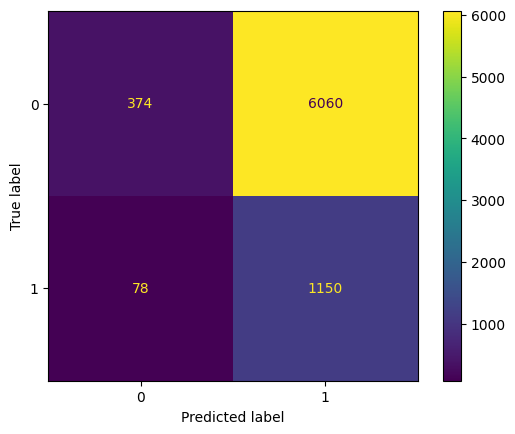

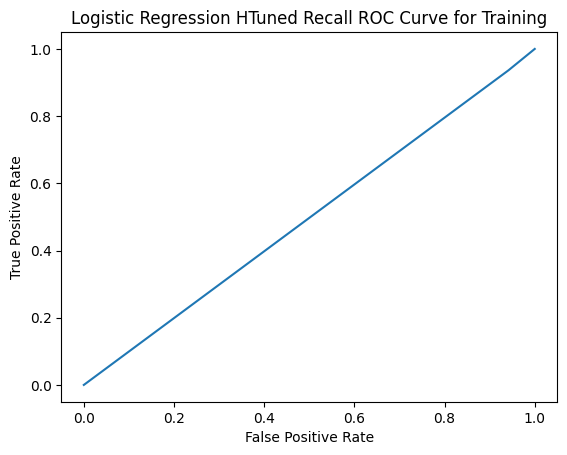

In [27]:
logRegGSRec = GridSearchCV(LogisticRegression(), param_grid = logRegParams, n_jobs = -1, cv = 5, scoring = 'recall')
logRegGSRecTrainPreds, logRegGSRecTrainConMat = modelRunTrain('Logistic Regression HTuned Recall', logRegGSRec)
plotRocTrain('Logistic Regression HTuned Recall', logRegGSRecTrainPreds)
addToTrainDF('Logistic Regression', logRegGSRec, 'Recall', 'No', logRegGSRecTrainConMat)

Classification report for Logistic Regression HTuned Recall testing set 
 
               precision    recall  f1-score   support

           0       0.79      0.04      0.08      1611
           1       0.16      0.94      0.27       305

    accuracy                           0.19      1916
   macro avg       0.47      0.49      0.18      1916
weighted avg       0.69      0.19      0.11      1916



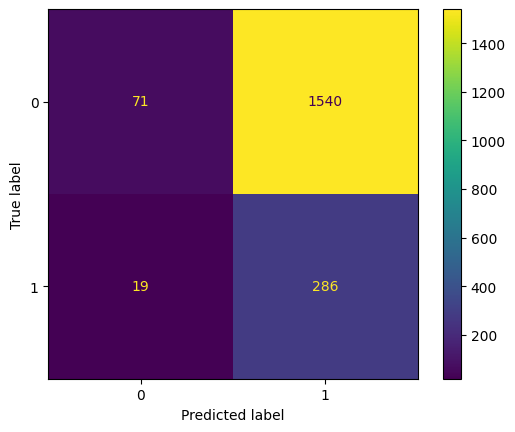

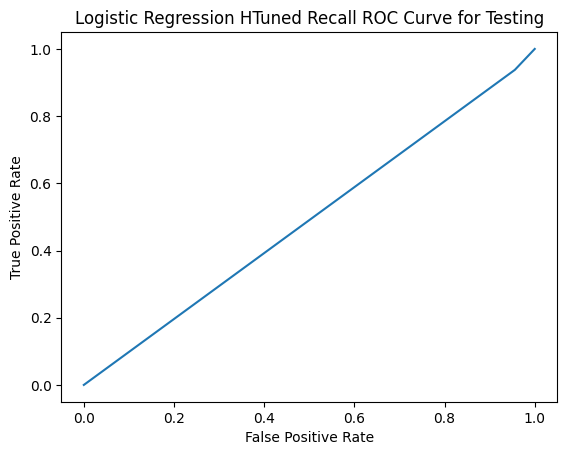

In [28]:
logRegGSRecTestPreds, logRegGSRecTestConMat = modelRunTest('Logistic Regression HTuned Recall', logRegGSRec)
plotRocTest('Logistic Regression HTuned Recall', logRegGSRecTestPreds)
addToTestDF('Logistic Regression', logRegGSRec, 'Recall', 'No', logRegGSRecTestConMat)

##### Tune for F1 Micro

Classification report for Logistic Regression HTuned F1 Micro training set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      6434
           1       1.00      0.00      0.00      1228

    accuracy                           0.84      7662
   macro avg       0.92      0.50      0.46      7662
weighted avg       0.87      0.84      0.77      7662



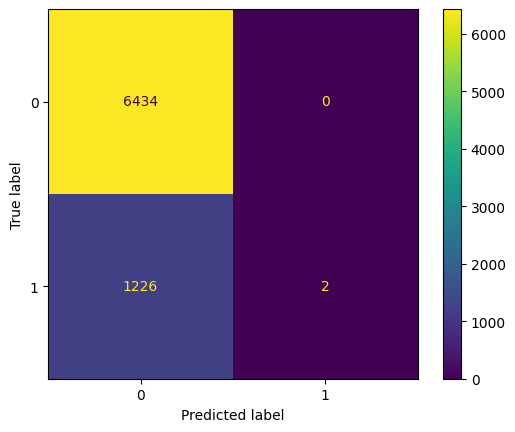

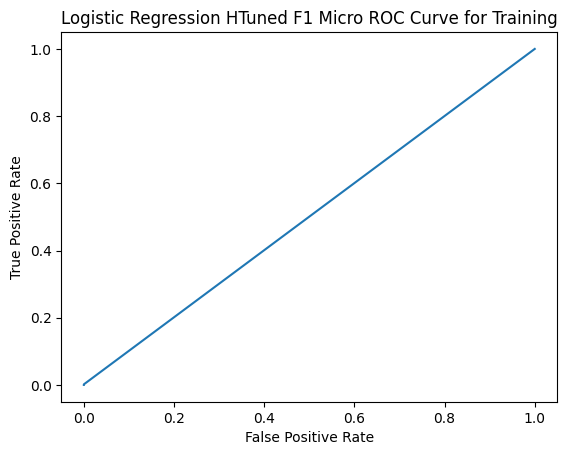

In [30]:
logRegGSF1Micro = GridSearchCV(LogisticRegression(), param_grid = logRegParams, n_jobs = -1, cv = 5, scoring = 'f1_micro')
logRegGSF1MicroTrainPreds, logRegGSF1MicroTrainConMat = modelRunTrain('Logistic Regression HTuned F1 Micro', logRegGSF1Micro)
plotRocTrain('Logistic Regression HTuned F1 Micro', logRegGSF1MicroTrainPreds)
addToTrainDF('Logistic Regression', logRegGSF1Micro, 'F1 Micro', 'No', logRegGSF1MicroTrainConMat)

Classification report for Logistic Regression HTuned F1 Micro testing set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      1611
           1       0.00      0.00      0.00       305

    accuracy                           0.84      1916
   macro avg       0.42      0.50      0.46      1916
weighted avg       0.71      0.84      0.77      1916



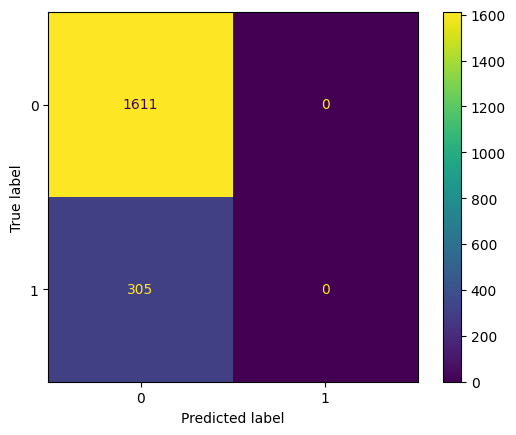

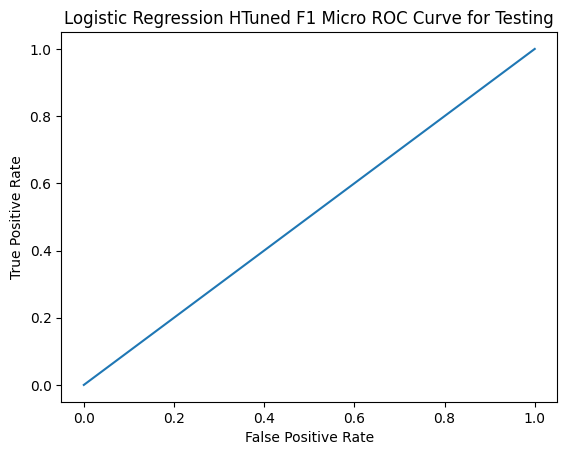

In [31]:
logRegGSF1MicroTestPreds, logRegGSF1MicroTestConMat = modelRunTest('Logistic Regression HTuned F1 Micro', logRegGSF1Micro)
plotRocTest('Logistic Regression HTuned F1 Micro', logRegGSF1MicroTestPreds)
addToTestDF('Logistic Regression', logRegGSF1Micro, 'F1 Micro', 'No', logRegGSF1MicroTestConMat)

##### Tune for F1 Weighted

Classification report for Logistic Regression HTuned F1 Weighted training set 
 
               precision    recall  f1-score   support

           0       0.84      0.99      0.91      6434
           1       0.35      0.02      0.04      1228

    accuracy                           0.84      7662
   macro avg       0.60      0.51      0.47      7662
weighted avg       0.76      0.84      0.77      7662



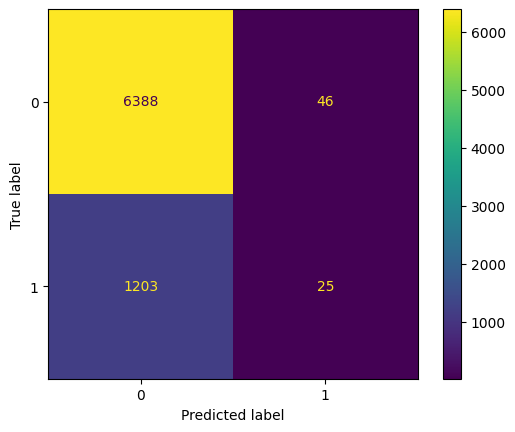

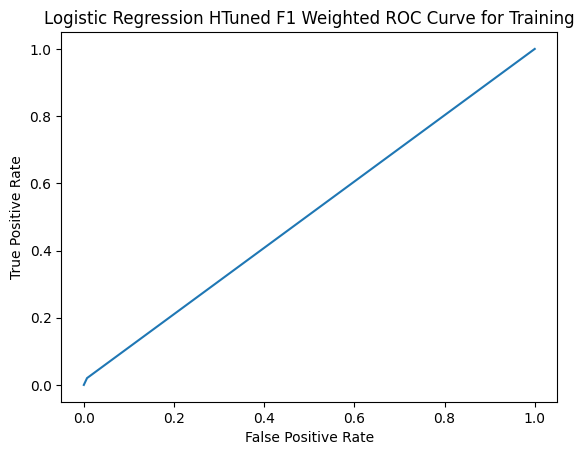

In [33]:
logRegGSF1Weighted = GridSearchCV(LogisticRegression(), param_grid = logRegParams, n_jobs = -1, cv = 5, scoring = 'f1_weighted')
logRegGSF1WeightedTrainPreds, logRegGSF1WeightedTrainConMat = modelRunTrain('Logistic Regression HTuned F1 Weighted', logRegGSF1Weighted)
plotRocTrain('Logistic Regression HTuned F1 Weighted', logRegGSF1WeightedTrainPreds)
addToTrainDF('Logistic Regression', logRegGSF1Weighted, 'F1 Weighted', 'No', logRegGSF1WeightedTrainConMat)

Classification report for Logistic Regression HTuned F1 Weighted testing set 
 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      1611
           1       0.38      0.02      0.03       305

    accuracy                           0.84      1916
   macro avg       0.61      0.51      0.47      1916
weighted avg       0.77      0.84      0.77      1916



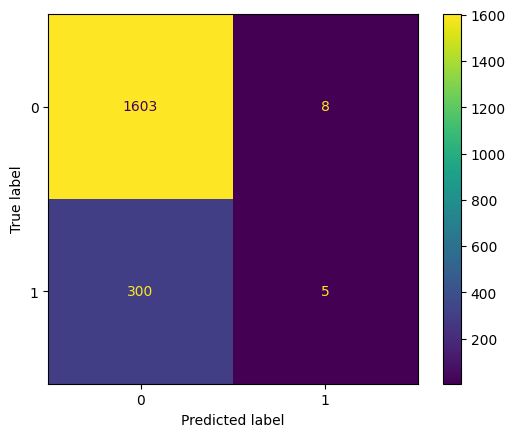

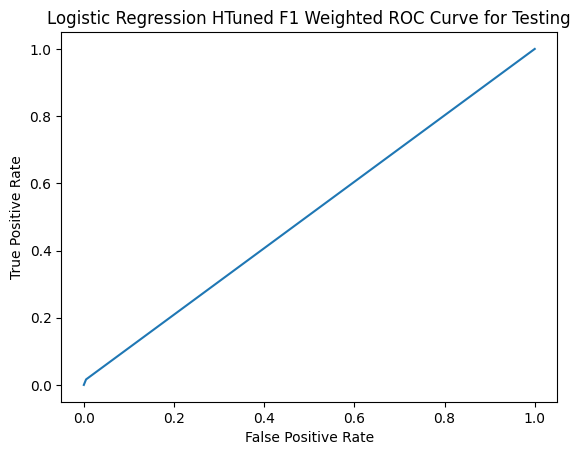

In [34]:
logRegGSF1WeightedTestPreds, logRegGSF1WeightedTestConMat = modelRunTest('Logistic Regression HTuned F1 Weighted', logRegGSF1Weighted)
plotRocTest('Logistic Regression HTuned F1 Weighted', logRegGSF1WeightedTestPreds)
addToTestDF('Logistic Regression', logRegGSF1Weighted, 'F1 Weighted', 'No', logRegGSF1WeightedTestConMat)

##### Tune for F2

Classification report for Logistic Regression HTuned F2 training set 
 
               precision    recall  f1-score   support

           0       0.83      0.06      0.11      6434
           1       0.16      0.94      0.27      1228

    accuracy                           0.20      7662
   macro avg       0.49      0.50      0.19      7662
weighted avg       0.72      0.20      0.13      7662



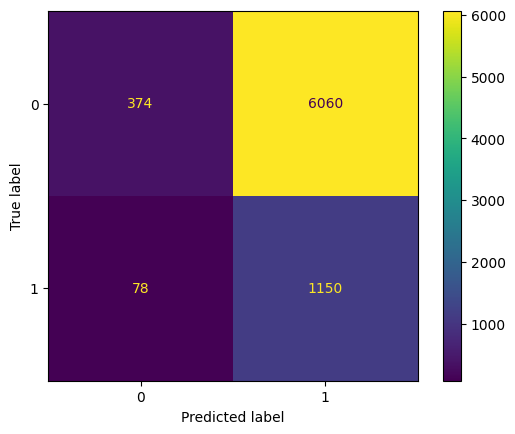

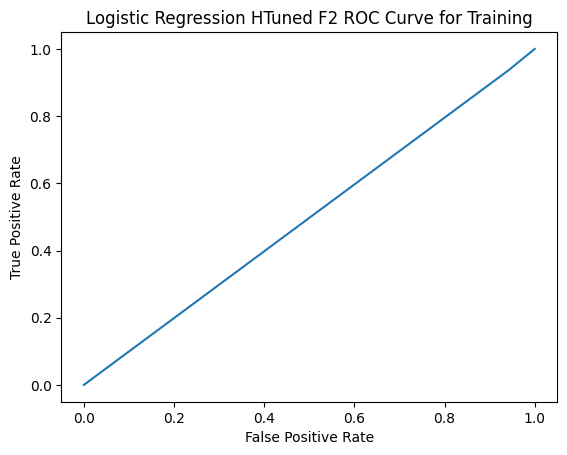

In [35]:
logRegGSF2 = GridSearchCV(LogisticRegression(), param_grid = logRegParams, n_jobs = -1, cv = 5, scoring = make_scorer(fbeta_score, beta = 2))
logRegGSF2TrainPreds, logRegGSF2TrainConMat = modelRunTrain('Logistic Regression HTuned F2', logRegGSF2)
plotRocTrain('Logistic Regression HTuned F2', logRegGSF2TrainPreds)
addToTrainDF('Logistic Regression', logRegGSF2, 'F2', 'No', logRegGSF2TrainConMat)

Classification report for Logistic Regression HTuned F2 testing set 
 
               precision    recall  f1-score   support

           0       0.79      0.04      0.08      1611
           1       0.16      0.94      0.27       305

    accuracy                           0.19      1916
   macro avg       0.47      0.49      0.18      1916
weighted avg       0.69      0.19      0.11      1916



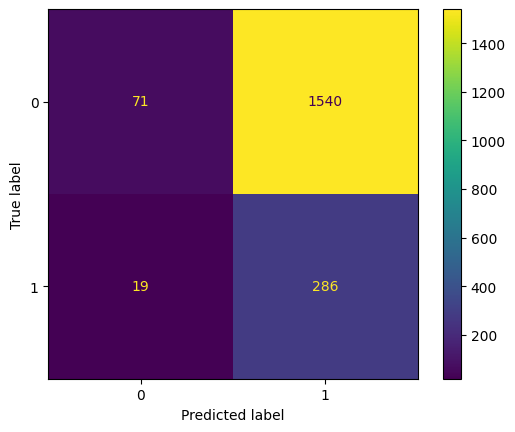

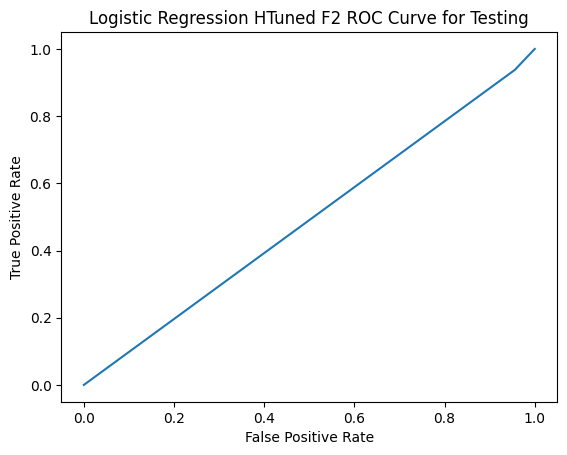

In [36]:
logRegGSF2TestPreds, logRegGSF2TestConMat = modelRunTest('Logistic Regression HTuned F2', logRegGSF2)
plotRocTest('Logistic Regression HTuned F2', logRegGSF2TestPreds)
addToTestDF('Logistic Regression', logRegGSF2, 'F2', 'No', logRegGSF2TestConMat)

#### With Threshold Tuning

##### HTuned for Balanced Accuracy


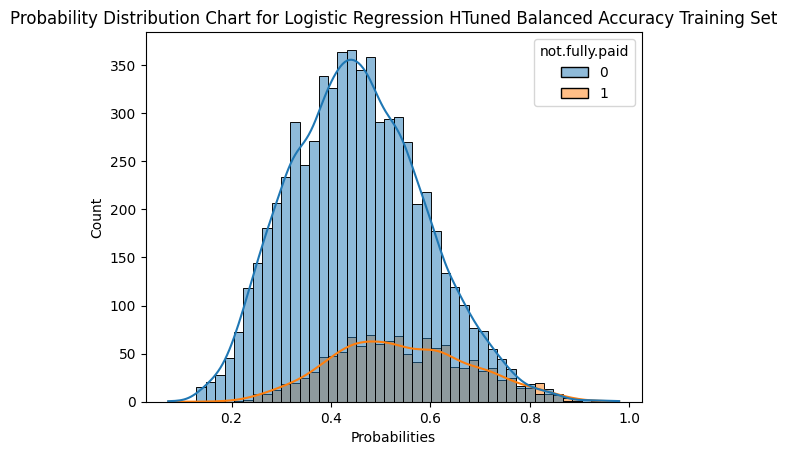

In [37]:
probDistTrain('Logistic Regression HTuned Balanced Accuracy', logRegGSAcc)

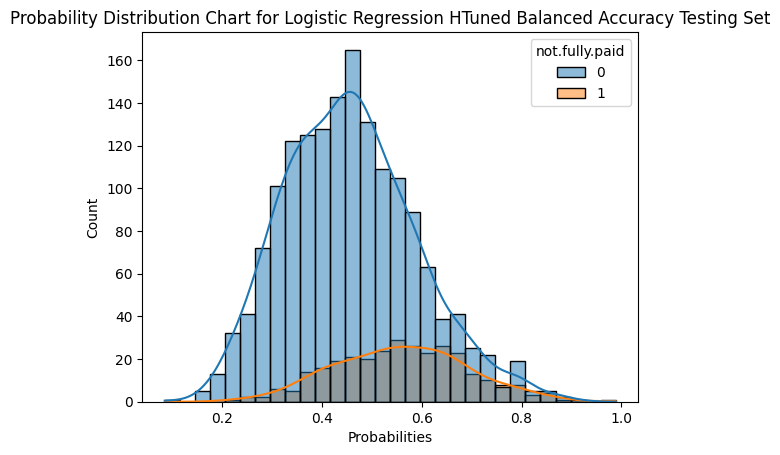

In [38]:
probDistTest('Logistic Regression HTuned Balanced Accuracy', logRegGSAcc)

###### TTuned for Balanced Accuracy

Classification report for Logistic Regression H and TTuned Balanced Accuracy training set 
 
               precision    recall  f1-score   support

           0       0.90      0.59      0.71      6434
           1       0.23      0.64      0.34      1228

    accuracy                           0.60      7662
   macro avg       0.56      0.62      0.53      7662
weighted avg       0.79      0.60      0.65      7662



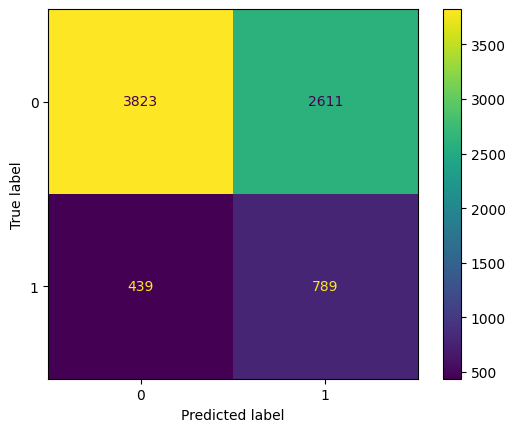

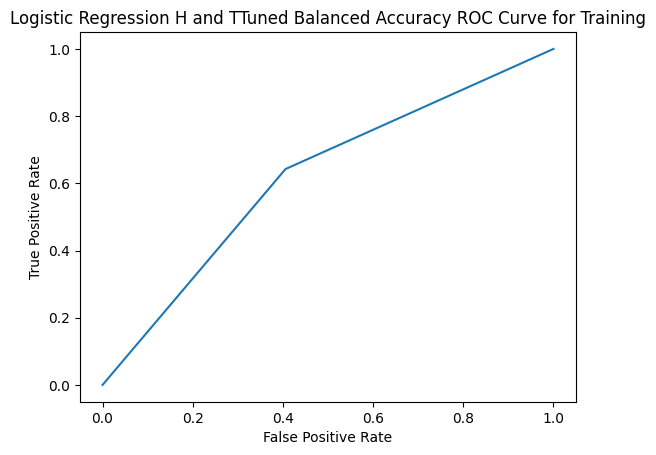

In [41]:
logRegGSAccTTunedAcc = TunedThresholdClassifierCV(estimator = logRegGSAcc.best_estimator_, cv = 5, scoring = 'balanced_accuracy')
logRegGSAccTTunedAccTrainPreds, logRegGSAccTTunedAccTrainConMat = modelRunTrain('Logistic Regression H and TTuned Balanced Accuracy', logRegGSAccTTunedAcc)
plotRocTrain('Logistic Regression H and TTuned Balanced Accuracy', logRegGSAccTTunedAccTrainPreds)
addToTrainDF('Logistic Regression', logRegGSAccTTunedAcc, 'Balanced Accuracy', 'Balanced Accuracy', logRegGSAccTTunedAccTrainConMat)

Classification report for Logistic Regression H and TTuned Balanced Accuracy testing set 
 
               precision    recall  f1-score   support

           0       0.92      0.60      0.72      1611
           1       0.25      0.71      0.37       305

    accuracy                           0.61      1916
   macro avg       0.58      0.65      0.55      1916
weighted avg       0.81      0.61      0.67      1916



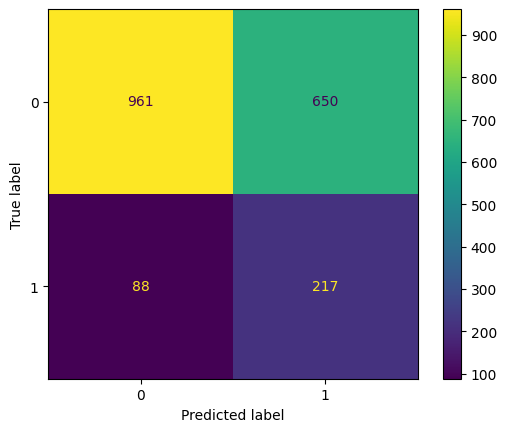

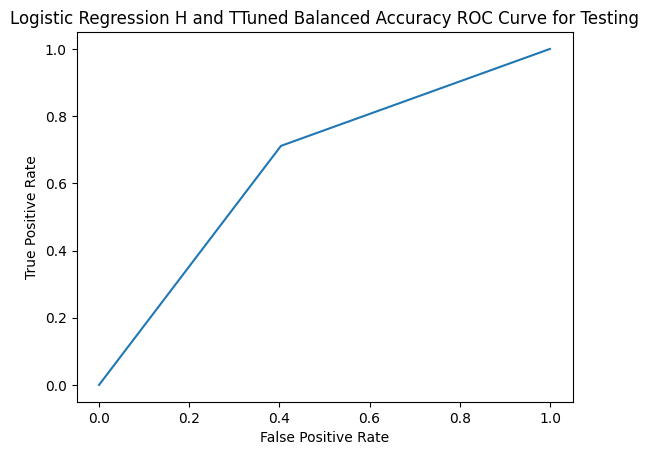

In [42]:
logRegGSAccTTunedAccTestPreds, logRegGSAccTTunedAccTestConMat = modelRunTest('Logistic Regression H and TTuned Balanced Accuracy', logRegGSAccTTunedAcc)
plotRocTest('Logistic Regression H and TTuned Balanced Accuracy', logRegGSAccTTunedAccTestPreds)
addToTestDF('Logistic Regression', logRegGSAccTTunedAcc, 'Balanced Accuracy', 'Balanced Accuracy', logRegGSAccTTunedAccTestConMat)

###### Tune for Recall

In [ ]:
logRegGSAccTTunedRec = TunedThresholdClassifierCV(logRegGSAcc.best_estimator_, cv = 5, scoring = 'recall')
logRegGSAccTTunedRecTrainPreds, logRegGSAccTTunedRecTrainConMat = modelRunTrain('Logistic Regression HTuned Balanced Accuracy TTuned Recall', logRegRec)
plotRocTrain('Logistic Regression TTuned Recall', logRegRecTrainPreds)
addToTrainDF('Logistic Regression', logRegRec, 'No', 'Recall', logRegRecTrainConMat)

In [ ]:
logRegRecTestPreds, logRegRecTestConMat = modelRunTest('Logistic Regression TTuned Recall', logRegRec)
plotRocTest('Logistic Regression TTuned Recall', logRegRecTestPreds)
addToTestDF('Logistic Regression', logRegRec, 'No', 'Recall', logRegRecTestConMat)

##### Tune for F1 Micro

In [ ]:
logRegF1 = TunedThresholdClassifierCV(LogisticRegression(), cv = 5, scoring = 'f1_micro')
logRegF1TrainPreds, logRegF1TrainConMat = modelRunTrain('Logistic Regression TTuned F1 Micro)', logRegF1)
plotRocTrain('Logistic Regression TTuned F1 Micro', logRegF1TrainPreds)
addToTrainDF('Logistic Regression', logRegF1, 'No', 'F1 Micro', logRegF1TrainConMat)

In [ ]:
logRegF1TestPreds, logRegF1TestConMat = modelRunTest('Logistic Regression TTuned F1 Micro', logRegF1)
plotRocTest('Logistic Regression TTuned F1 Micro', logRegF1TestPreds)
addToTestDF('Logistic Regression', logRegF1, 'No', 'F1 Micro', logRegF1TestConMat)

##### Tune for F1 Weighted

In [ ]:
logRegF1 = TunedThresholdClassifierCV(LogisticRegression(), cv = 5, scoring = 'f1_weighted')
logRegF1TrainPreds, logRegF1TrainConMat = modelRunTrain('Logistic Regression TTuned F1 Weighted)', logRegF1)
plotRocTrain('Logistic Regression TTuned F1 Weighted', logRegF1TrainPreds)
addToTrainDF('Logistic Regression', logRegF1, 'No', 'F1 Weighted', logRegF1TrainConMat)

In [ ]:
logRegF1TestPreds, logRegF1TestConMat = modelRunTest('Logistic Regression TTuned F1 Weighted', logRegF1)
plotRocTest('Logistic Regression TTuned F1 Weighted', logRegF1TestPreds)
addToTestDF('Logistic Regression', logRegF1, 'No', 'F1 Weighted', logRegF1TestConMat)

##### Tune for F2

In [ ]:
logRegF2 = TunedThresholdClassifierCV(LogisticRegression(), cv = 5, scoring = make_scorer(fbeta_score, beta = 2))
logRegF2TrainPreds, logRegF2TrainConMat = modelRunTrain('Logistic Regression TTuned F2', logRegF2)
plotRocTrain('Logistic Regression TTuned F2', logRegF2TrainPreds)
addToTrainDF('Logistic Regression', logRegF2, 'No', 'F2', logRegF2TrainConMat)

In [ ]:
logRegF2TestPreds, logRegF2TestConMat = modelRunTest('Logistic Regression TTuned F2', logRegF2)
plotRocTest('Logistic Regression TTuned F2', logRegF2TestPreds)
addToTestDF('Logistic Regression', logRegF2, 'No', 'F2', logRegF2TestConMat)

In [45]:
statsTrain.to_csv('statsTrain.csv')
statsTest.to_csv('statsTest.csv')

,Unnamed: 0,Model,HTuned,Params,TTuned,Threshold,TP,TN,FP,FN
0,0,Logistic Regression,Balanced Accuracy,"{'cv': 5, 'error_score': nan, 'estimator__C': ...",No,0.5000,206,1051,560,99
1,1,Logistic Regression,Recall,"{'cv': 5, 'error_score': nan, 'estimator__C': ...",No,0.5000,286,71,1540,19
2,2,Logistic Regression,F1 Micro,"{'cv': 5, 'error_score': nan, 'estimator__C': ...",No,0.5000,0,1611,0,305
3,3,Logistic Regression,F1 Weighted,"{'cv': 5, 'error_score': nan, 'estimator__C': ...",No,0.5000,5,1603,8,300
4,4,Logistic Regression,F2,"{'cv': 5, 'error_score': nan, 'estimator__C': ...",No,0.5000,286,71,1540,19
5,5,Logistic Regression,Balanced Accuracy,"{'cv': 5, 'estimator__C': 5, 'estimator__class...",Balanced Accuracy,0.4803,217,961,650,88
